In [4]:
# Test imports
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import skimage

# Print versions
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {sp.__version__}")
print(f"scikit-image version: {skimage.__version__}")
print("✓ MIP environment is working perfectly!")

NumPy version: 1.26.1
SciPy version: 1.13.1
scikit-image version: 0.24.0
✓ MIP environment is working perfectly!


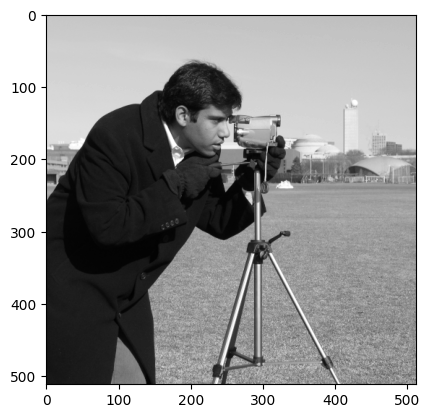

In [5]:
from skimage import data
cameraman = data.camera()  # Load the image
plt.imshow(cameraman, cmap='gray')  # Display it
plt.show()  # Show the window

In [2]:
import sys
print(sys.executable)

/opt/anaconda3/envs/MIPP/bin/python


In [9]:
#inverted
cameraman_inverted = 255 - cameraman


In [10]:
#cameraman upside down 
cameraman_upside_down = np.rot90(cameraman,2)

In [11]:
#Load color image
color_image = data.astronaut()

In [13]:
#split into RGB channels
red_channel = color_image[:, :, 0]
green_channel = color_image[:, :, 1]
blue_channel = color_image[:, :, 2]

(-0.5, 511.5, 511.5, -0.5)

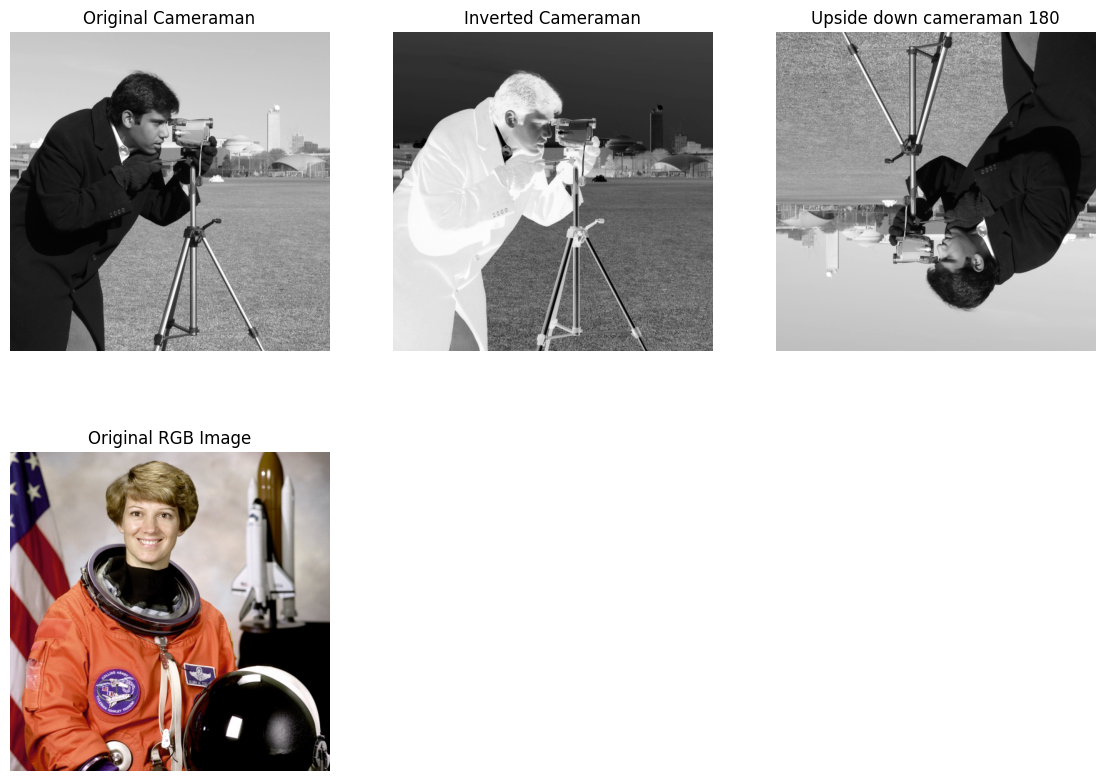

In [18]:
#Display all results
#Create the figure with subplots
fig = plt.figure(figsize=(14,10))

#Plot 1 : Original Cameraman
ax1 = fig.add_subplot(2,3,1)
ax1.imshow(cameraman,cmap='gray')
ax1.set_title('Original Cameraman')
ax1.axis('off')

#Plot 2: Inverted Cameraman
ax2 = fig.add_subplot(2,3,2)
ax2.imshow(cameraman_inverted,cmap='gray')
ax2.set_title('Inverted Cameraman')
ax2.axis('off')

#Plot 3: Upside down Cameraman
ax3 = fig.add_subplot(2,3,3)
ax3.imshow(cameraman_upside_down,cmap='gray')
ax3.set_title('Upside down cameraman 180')
ax3.axis('off')

#Plot 4: Original RGB image
ax4 = fig.add_subplot(2,3,4)
ax4.imshow(color_image)
ax4.set_title('Original RGB Image')
ax4.axis('off')


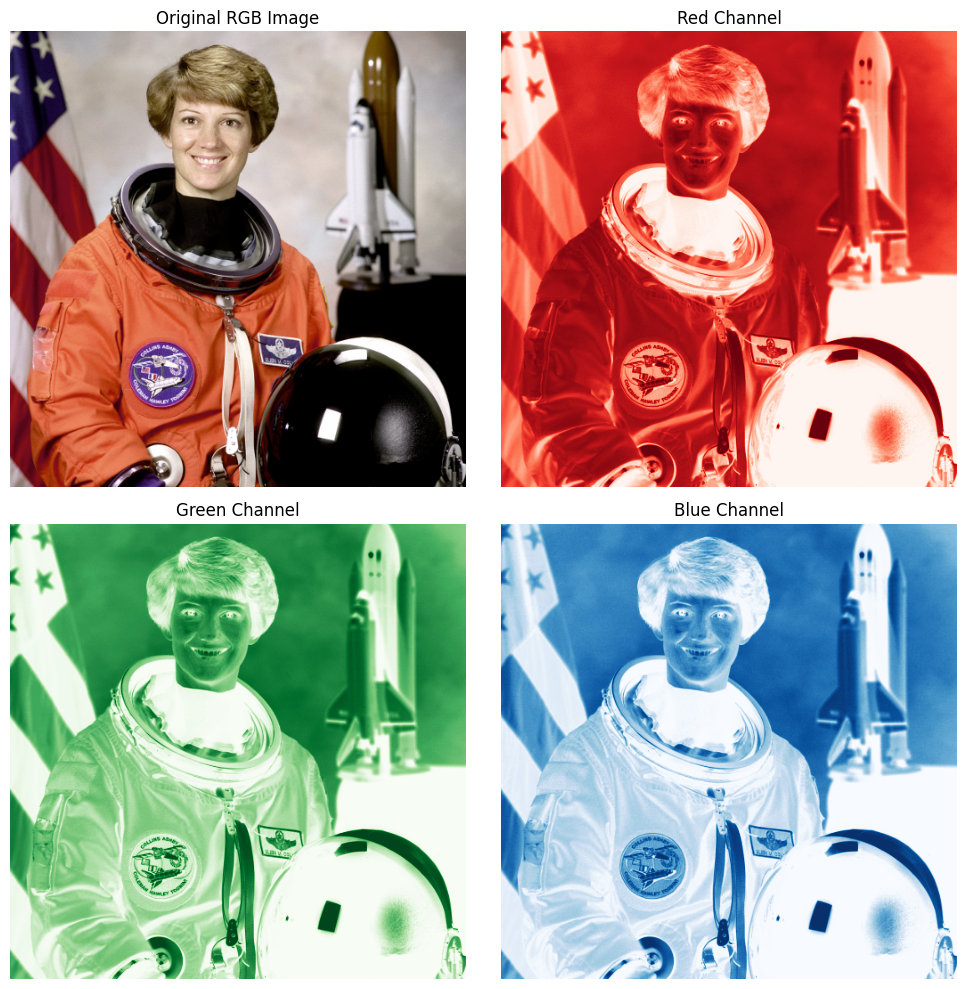

In [33]:
# Plot 5: All three channels in one plot (2x2 grid)
fig2,axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(color_image)
axes[0, 0].set_title('Original RGB Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(red_channel, cmap='Reds')
axes[0, 1].set_title('Red Channel')
axes[0, 1].axis('off')

axes[1, 0].imshow(green_channel, cmap='Greens')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(blue_channel, cmap='Blues')
axes[1, 1].set_title('Blue Channel')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()



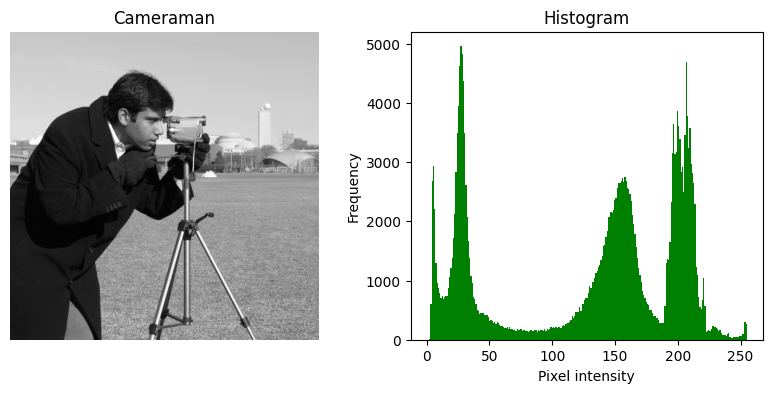

In [40]:


# Load image
cameraman = data.camera()

# Simple histogram using matplotlib
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cameraman, cmap='gray')
plt.title('Cameraman')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(cameraman.ravel(), bins=256, color='green')
plt.title('Histogram')
plt.xlabel('Pixel intensity')
plt.ylabel('Frequency')

plt.show()

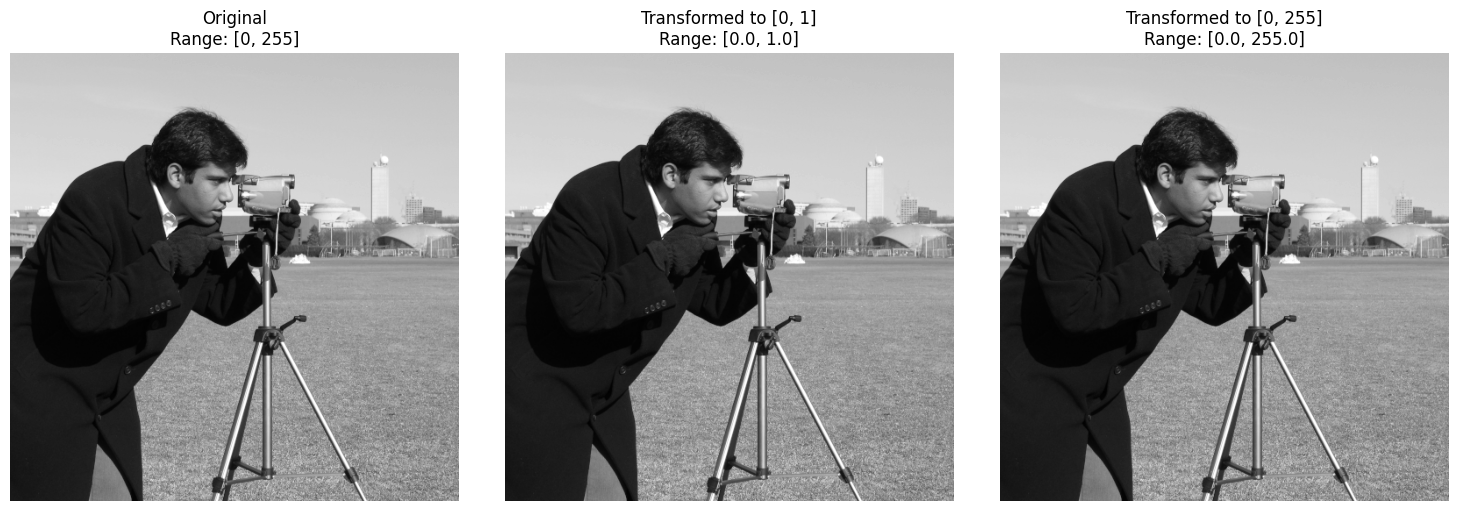

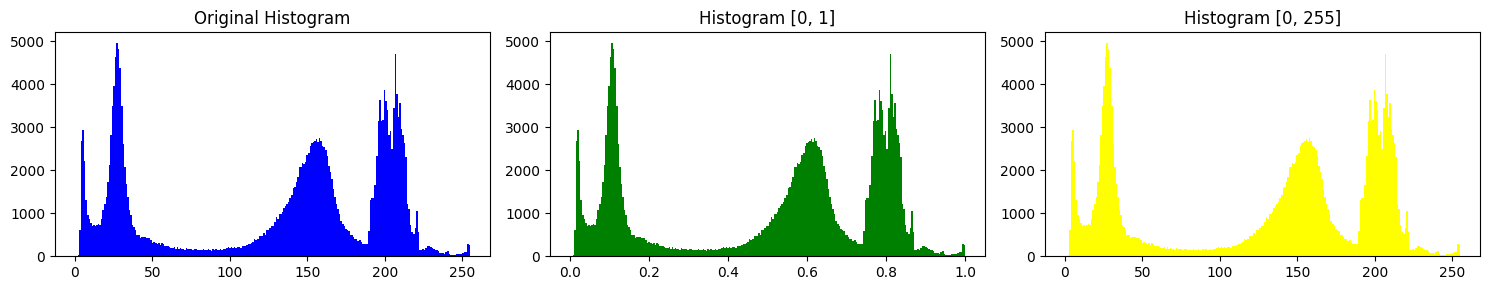

In [48]:


def hist_linear(I, range_min, range_max):
    """
    Linearly transforms the histogram of image I to new range [range_min, range_max]
    """
    # Get current min and max of image
    current_max = np.max(I)
    
    # Apply linear transformation
    I_transformed = (I) / (current_max) * (range_max )    
    return I_transformed

# Test it
cameraman = data.camera()

# Transform to different ranges
result_0_1 = hist_linear(cameraman, 0, 1)
result_0_255 = hist_linear(cameraman, 0, 255)

# Display results
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(cameraman, cmap='gray')
plt.title(f'Original\nRange: [{cameraman.min()}, {cameraman.max()}]')
plt.axis('off')

# Transformed to [0, 1]
plt.subplot(1, 3, 2)
plt.imshow(result_0_1, cmap='gray')
plt.title(f'Transformed to [0, 1]\nRange: [{result_0_1.min():.1f}, {result_0_1.max():.1f}]')
plt.axis('off')

# Transformed to [0, 255]
plt.subplot(1, 3, 3)
plt.imshow(result_0_255, cmap='gray')
plt.title(f'Transformed to [0, 255]\nRange: [{result_0_255.min()}, {result_0_255.max()}]')
plt.axis('off')

plt.tight_layout()
plt.show()

# Show histograms
plt.figure(figsize=(15, 3))

plt.subplot(1, 3, 1)
plt.hist(cameraman.ravel(), bins=256, color='blue')
plt.title('Original Histogram')

plt.subplot(1, 3, 2)
plt.hist(result_0_1.ravel(), bins=256, color='green')
plt.title('Histogram [0, 1]')

plt.subplot(1, 3, 3)
plt.hist(result_0_255.ravel(), bins=256, color='yellow')
plt.title('Histogram [0, 255]')

plt.tight_layout()
plt.show()

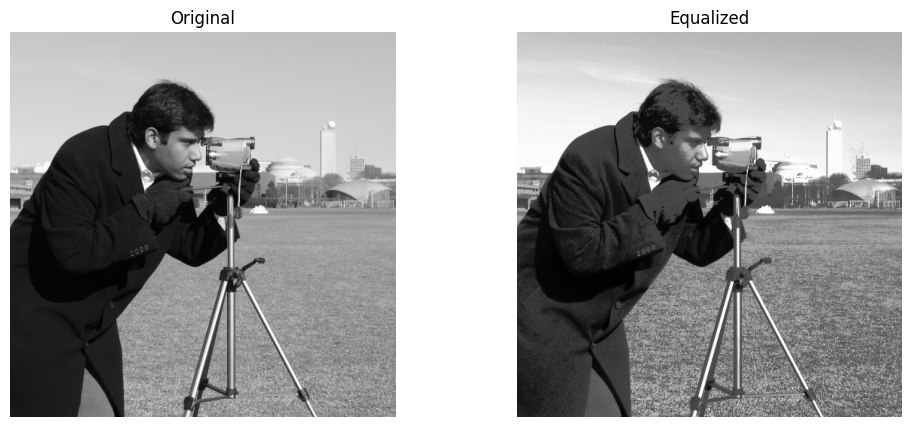

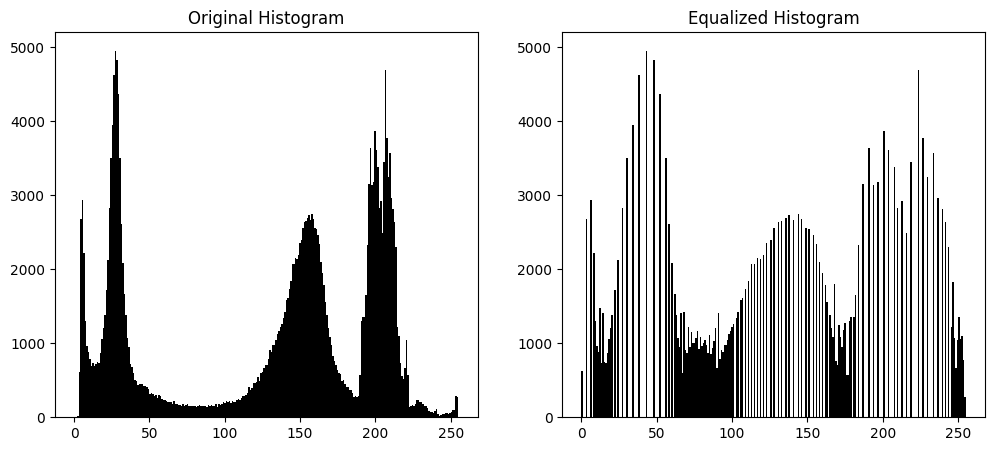

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

def hist_eq(I):
    """
    Performs histogram equalization on image I
    """
    # Make sure I is a 2D array
    if len(I.shape) > 2:
        I = I[:, :, 0]  # Take first channel if RGB
    
    # Convert to 1D array
    pixels = I.flatten()
    
    # Calculate histogram
    hist = np.zeros(256)
    for p in pixels:
        hist[p] += 1
    
    # Calculate cumulative sum
    cdf = np.zeros(256)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    
    # Normalize
    cdf_min = cdf[cdf > 0].min()
    total_pixels = pixels.size
    
    # Create mapping
    mapping = np.zeros(256)
    for i in range(256):
        mapping[i] = (cdf[i] - cdf_min) * 255 / (total_pixels - cdf_min)
    
    # Apply mapping
    I_equalized = mapping[I]
    
    return I_equalized.astype(np.uint8)

# Load image
cameraman = data.camera()

# Apply equalization
equalized = hist_eq(cameraman)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cameraman, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.title('Equalized')
plt.axis('off')

plt.show()

# Show histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(cameraman.flatten(), bins=256, color='black')
plt.title('Original Histogram')

plt.subplot(1, 2, 2)
plt.hist(equalized.flatten(), bins=256, color='black')
plt.title('Equalized Histogram')

plt.show()